# NYC 独立日评估：方法对比

读取 `results/nye_results` 的六份原始 Excel，不修改工作簿。
结果另存 `paper_figures_single/` 和 `analysis_single/`，不覆盖原图。

- 图 1：日均收益、未获同轮补救的拒单量、平均电量、补救覆盖率。
- 图 2：一张图比较六种方法的每小时完成量均值与 95% 按天 t 区间，灰色曲线为共同外部需求的 KDE。
- LaTeX 表格使用完整方法名称，区分 Myopic、Learning 和 Decoupled。

In [35]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'results/nye_results').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('请从 icaps 项目或其子目录运行 notebook。')
DATA_DIR = ROOT / 'results/nye_results'
FIG_DIR = DATA_DIR / 'paper_figures_single'
ANALYSIS_DIR = DATA_DIR / 'analysis_single'
FIG_DIR.mkdir(exist_ok=True)
ANALYSIS_DIR.mkdir(exist_ok=True)
EPOCH_SECONDS = 30.0  # 与这些导出结果的 NYC 测试设置一致
SPECS = [
    ('benchmark_r1', 'Myopic r1', 'MCMF', 'r1', '#697786'),
    ('benchmark_r2', 'Myopic r2', 'MCMF', 'r2', '#b28c57'),
    ('r1', 'Learning r1', 'ADP-MCMF', 'r1', '#4c78a8'),
    ('r2', 'Learning r2', 'ADP-MCMF', 'r2', '#9b6cb3'),
    ('r3', 'Learning r3', 'ADP-MCMF', 'r3', '#e48144'),
    ('macro', 'Recourse', 'ADP-MCMF', 'macro', '#219b89'),
]
ORDER = [s[1] for s in SPECS]
DISPLAY_LABELS = {label: ('Decoupled r3' if label == 'Learning r3' else label) for label in ORDER}
COLORS = {s[1]: s[4] for s in SPECS}
STYLE = {label: '--' if label.startswith('Myopic') else '-' for label in ORDER}
mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': .18, 'axes.axisbelow': True,
    'figure.dpi': 300, 'savefig.dpi': 300, 'pdf.fonttype': 42,
})
FIGURES = []

def save_show(fig, name, description):
    for suffix in ['png', 'pdf']:
        fig.savefig(FIG_DIR / f'{name}.{suffix}', bbox_inches='tight', facecolor='white')
    FIGURES.append({'name': name, 'description': description})
    plt.show()
    plt.close(fig)

def line(ax, label, x, y, **kwargs):
    ax.plot(x, y, color=COLORS[label], linestyle=STYLE[label],
            linewidth=2.1, label=label, **kwargs)

def bars(ax, values, title, ylabel, fmt='.1f'):
    values = np.asarray(values, dtype=float)
    rects = ax.bar(np.arange(len(ORDER)), values, color=[COLORS[s] for s in ORDER], width=.7)
    for label, rect in zip(ORDER, rects):
        if label.startswith('Myopic'):
            rect.set_hatch('//')
            rect.set_edgecolor('white')
    ax.bar_label(rects, labels=[format(v, fmt) if np.isfinite(v) else 'n/a' for v in values],
                 padding=4, fontsize=9)
    ax.set_xticks(range(len(ORDER)), [DISPLAY_LABELS[x].replace(' ', '\n', 1) for x in ORDER])
    ax.set(title=title, ylabel=ylabel)
    ax.set_ylim(0, max(float(np.max(values[np.isfinite(values)])) * 1.19, 1) if np.isfinite(values).any() else 1)
    ax.grid(axis='x', visible=False)

## 统计口径

每种方法一个种子、三天独立初始化的评估；三天需求不同，不是同一天的三次随机种子重复。

- 收益、EV/AEV 完成量使用日均；`complete`、`recourse_requests`、`lost_requests` 为三天合计。
- `avg_battery_level` 是**三个日末车队平均 SoC 的均值**，图中换成百分数。它包含 EV 和 AEV，不能解释为全天时间平均电量。
- 第二张图每种方法的线为三天相同小时的完成量均值。彩色带为逐小时 $\bar x\pm t_{0.975,n-1}s/\sqrt n$，$n=3$，是按天计算的名义 95% t 区间；仅供描述这三天的变化，不是跨种子的置信区间，也不是同时覆盖全天的置信带。只有三天且日期需求不同，不能用此图宣称算法显著优胜。原始区间保存在 CSV 中，绘图下界截在 0。
- 灰色需求曲线：每一天用小时中心、小时需求量作为权重计算 KDE，再对三天取均值，单位仍为单/小时。灰色填充是需求背景，不是置信带。各方法外部需求相同，不能把它画成六组不同需求。
- Recourse rate = 去重同轮补救指派订单 / 去重 EV 拒单订单。补救指派不等于完成；旧表缺少补救完成字段时显示 n/a。

In [36]:
compare_lists = ['strategy', 'mode', 'demand', 'seed', 'avg_reward', 'mean_ev_completed_orders', 'mean_aev_completed_orders', 'episode_reward_ev', 'episode_reward_aev','mean_drop_off_rate','mean_assignment_success_rate_pct']

In [37]:
SHEETS = ['detail', 'daily_req_completion_summary', 'hourly_req_completion_summary',
          'hourly_completed_summary', 'hourly_station_queue_summary', 'hourly_zone_vehicle_summary']
books, source_info = {}, []
for suffix, label, strategy, method, color in SPECS:
    path = DATA_DIR / f'test_results_4way_optimization_anchored_residual_{suffix}.xlsx'
    book = pd.read_excel(path, sheet_name=SHEETS)
    for sheet, frame in book.items():
        assert set(frame['strategy']) == {strategy}, (label, sheet, 'strategy mismatch')
        assert set(frame['method']) == {method}, (label, sheet, 'method mismatch')
        for col in ['date', 'request_date', 'completed_date']:
            if col in frame:
                frame[col] = pd.to_datetime(frame[col]).dt.normalize()
    # 当前文件只含一个种子。以后合并多种子时应显式新增种子层级，不能静默当日平均。
    assert len(book['detail']) == 1, f'{label}: 请为多种子结果增加种子层级聚合。'
    books[label] = book
    source_info.append({'label': label, 'file': path.name,
                        'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})

raw = pd.concat([b['detail'].assign(label=label) for label, b in books.items()], ignore_index=True).set_index('label').loc[ORDER]
assert raw['seed'].nunique() == 1, '比较必须使用相同种子。'
assert raw['episodes'].nunique() == 1
N_DAYS = int(raw['episodes'].iloc[0])
SEED = int(raw['seed'].iloc[0])
DATES = sorted(books[ORDER[0]]['daily_req_completion_summary']['request_date'].unique())
assert len(DATES) == N_DAYS
PERIOD = f'{pd.Timestamp(DATES[0]):%Y-%m-%d} to {pd.Timestamp(DATES[-1]):%Y-%m-%d}; seed {SEED}'
ref_demand = None
validation_rows = []
for label, book in books.items():
    d = book['daily_req_completion_summary']
    h = book['hourly_completed_summary']
    q = book['hourly_req_completion_summary']
    assert not d.duplicated(['request_date', 'zone_id']).any()
    assert not h.duplicated(['completed_date', 'completed_hour']).any()
    assert not q.duplicated(['request_date', 'request_hour', 'zone_id']).any()
    assert sorted(d.request_date.unique()) == DATES
    demand = q.set_index(['request_date', 'request_hour', 'zone_id']).generated_requests.sort_index()
    if ref_demand is None:
        ref_demand = demand
    else:
        idx = ref_demand.index.union(demand.index)
        np.testing.assert_allclose(ref_demand.reindex(idx, fill_value=0), demand.reindex(idx, fill_value=0))
    r = raw.loc[label]
    np.testing.assert_allclose(d.generated_requests.sum(), r.total_orders)
    np.testing.assert_allclose(q.generated_requests.sum(), r.total_orders)
    np.testing.assert_allclose(d.completed_requests.sum(), r.complete)
    np.testing.assert_allclose(q.completed_requests.sum(), r.complete)
    np.testing.assert_allclose(h.mean_completed_orders.sum(), r.complete)
    np.testing.assert_allclose(h.mean_completed_ev_orders + h.mean_completed_aev_orders, h.mean_completed_orders)
    np.testing.assert_allclose(r.avg_reward * N_DAYS, r.total_reward)
    np.testing.assert_allclose(r.episode_reward_ev + r.episode_reward_aev, r.avg_reward)
    np.testing.assert_allclose((r.mean_ev_completed_orders + r.mean_aev_completed_orders) * N_DAYS, r.complete)
    validation_rows.append({'Method': label, 'Seed': SEED, 'Days': N_DAYS,
                            'Demand total': int(r.total_orders), 'Completed total': int(r.complete)})
display(pd.DataFrame(validation_rows))
print('Validated: same hourly/zone demand, same seed/dates, reward and completion totals reconcile.')
# 保留原 notebook 的便捷变量名。
data_benchmark_r1, data_benchmark_r2, data_r1, data_r2, data_r3, data_macro = [books[k]['detail'] for k in ORDER]

,Method,Seed,Days,Demand total,Completed total
0,Myopic r1,256,3,358212,282334
1,Myopic r2,256,3,358212,327808
2,Learning r1,256,3,358212,275164
3,Learning r2,256,3,358212,327576
4,Learning r3,256,3,358212,276350
5,Recourse,256,3,358212,301080


Validated: same hourly/zone demand, same seed/dates, reward and completion totals reconcile.


In [38]:
raw.columns

Index(['conservative_charging', 'checkpoint_conservative_charging',
       'charging_model_source', 'strategy', 'method', 'seed', 'avg_reward',
       'total_reward', 'episodes', 'total_orders', 'accept', 'reject',
       'rejected_requests', 'recourse_requests', 'lost_requests', 'complete',
       'mean_ev_completed_orders', 'mean_aev_completed_orders',
       'mean_assignment_success_rate', 'mean_completed_order_value',
       'mean_ev_completed_order_value', 'mean_aev_completed_order_value',
       'mean_service_ratio', 'max_station_pressure',
       'mean_max_station_pressure', 'mean_station_pressure',
       'mean_max_station_pressure_ratio', 'mean_station_pressure_ratio',
       'avg_wait', 'waiting_vehicle_count', 'mean_waiting_vehicle_count',
       'episode_reward_aev', 'episode_reward_ev', 'episode_aev_reward',
       'episode_ev_reward', 'avg_battery_level', 'finished_charge',
       'avg_daily_charging_sessions_per_human_ev',
       'avg_daily_charging_sessions_per_vehicle'

In [39]:
compare_lists = ['strategy', 'avg_reward', 'mean_ev_completed_orders', 'mean_aev_completed_orders', 'episode_reward_ev', 'episode_reward_aev', 'mean_service_ratio']

In [40]:
# 每行用完整方法名，避免四个 learning 方法都只显示 ADP-MCMF。
latex_table_data = pd.DataFrame({
    'Method': [DISPLAY_LABELS[k] for k in ORDER],
    'Reward ($/day)': raw.avg_reward.to_numpy(),
    'EV complete (/day)': raw.mean_ev_completed_orders.to_numpy(),
    'AEV complete (/day)': raw.mean_aev_completed_orders.to_numpy(),
    'EV reward ($/day)': raw.episode_reward_ev.to_numpy(),
    'AEV reward ($/day)': raw.episode_reward_aev.to_numpy(),
    'Service rate (%)': (100 * raw.mean_service_ratio).to_numpy(),
})
latex_table_data.insert(0, 'ID', np.arange(1, len(latex_table_data) + 1))

def latex_number(value):
    if not np.isfinite(value):
        return '--'
    if abs(value) >= 1000:
        mantissa, exponent = f'{value:.2e}'.split('e')
        return rf'${mantissa}\times 10^{{{int(exponent)}}}$'
    return f'{value:.2f}'

latex_lines = [r'\begin{table*}[t]', r'\centering', r'\small',
    r'\caption{NYC independent-day evaluation. Rewards and completed orders are daily means; service rate is the mean of daily rates. ' + PERIOD.replace(';', ',') + '.}',
    r'\label{tab:nyc-single-policy-comparison}',
    r'\begin{tabular}{rlrrrrrr}', r'\toprule',
    r'ID & Method & Reward (\$/day) & EV completed/day & AEV completed/day & EV reward (\$/day) & AEV reward (\$/day) & Service (\%) \\',
    r'\midrule']
for row in latex_table_data.itertuples(index=False, name=None):
    latex_lines.append(' & '.join([str(row[0]), row[1], *[latex_number(v) for v in row[2:]]]) + r' \\')
latex_lines.extend([r'\bottomrule', r'\end{tabular}', r'\end{table*}'])
latex_code = '\n'.join(latex_lines)
print(latex_code)
(ANALYSIS_DIR / 'policy_comparison.tex').write_text(latex_code + '\n')
latex_table_data.to_csv(ANALYSIS_DIR / 'policy_comparison_table.csv', index=False)

\begin{table*}[t]
\centering
\small
\caption{NYC independent-day evaluation. Rewards and completed orders are daily means; service rate is the mean of daily rates. 2025-12-15 to 2025-12-17, seed 256.}
\label{tab:nyc-single-policy-comparison}
\begin{tabular}{rlrrrrrr}
\toprule
ID & Method & Reward (\$/day) & EV completed/day & AEV completed/day & EV reward (\$/day) & AEV reward (\$/day) & Service (\%) \\
\midrule
1 & Myopic r1 & $1.93\times 10^{6}$ & $5.11\times 10^{4}$ & $4.30\times 10^{4}$ & $1.33\times 10^{6}$ & $6.05\times 10^{5}$ & 78.80 \\
2 & Myopic r2 & $2.09\times 10^{6}$ & $3.99\times 10^{4}$ & $6.94\times 10^{4}$ & $8.57\times 10^{5}$ & $1.23\times 10^{6}$ & 91.66 \\
3 & Learning r1 & $2.64\times 10^{6}$ & $5.78\times 10^{4}$ & $3.39\times 10^{4}$ & $2.12\times 10^{6}$ & $5.11\times 10^{5}$ & 77.16 \\
4 & Learning r2 & $2.16\times 10^{6}$ & $3.76\times 10^{4}$ & $7.16\times 10^{4}$ & $8.94\times 10^{5}$ & $1.27\times 10^{6}$ & 91.60 \\
5 & Decoupled r3 & $2.56\times 10^{6}$ &

In [41]:
metrics = pd.DataFrame(index=ORDER)
metrics.index.name = 'Method'
metrics['reward_per_day'] = raw.avg_reward
metrics['completed_per_day'] = raw.complete / N_DAYS
metrics['service_pooled_pct'] = 100 * raw.complete / raw.total_orders
metrics['service_daily_mean_pct'] = 100 * raw.mean_service_ratio
metrics['charging_wait_positive_records_min'] = raw.avg_wait * EPOCH_SECONDS / 60
metrics['waiting_records_per_day'] = raw.waiting_vehicle_count / N_DAYS
metrics['completed_charges_per_day'] = raw.finished_charge
metrics['mean_daily_final_soc_pct'] = raw.avg_battery_level * 100
metrics['recourse_per_day'] = raw.recourse_requests / N_DAYS
metrics['lost_requests_per_day'] = raw.lost_requests / N_DAYS
metrics['rejected_unique_per_day'] = raw.rejected_requests / N_DAYS

# 去重订单口径：recourse 是 EV-rejected 订单的子集；不能用重复拒单事件数 reject。
assert raw[['rejected_requests', 'recourse_requests']].notna().all().all()
assert (raw.recourse_requests >= 0).all()
assert (raw.rejected_requests >= raw.recourse_requests).all()
metrics['rejected_without_same_epoch_recourse_total'] = raw.rejected_requests - raw.recourse_requests
metrics['rejected_without_same_epoch_recourse_per_day'] = metrics.rejected_without_same_epoch_recourse_total / N_DAYS
metrics['recourse_rate_pct'] = 100 * raw.recourse_requests / raw.rejected_requests.replace(0, np.nan)
# 老版 Excel 没有补救完成计数，不能从总完成量推断。
for optional in ['recourse_assigned_requests', 'recourse_completed_requests', 'recourse_uncompleted_requests']:
    if optional not in raw:
        raw[optional] = np.nan
known = raw.recourse_assigned_requests.notna()
np.testing.assert_allclose(raw.loc[known, 'recourse_assigned_requests'], raw.loc[known, 'recourse_requests'])
metrics['recourse_completion_success_pct'] = 100 * raw.recourse_completed_requests / raw.recourse_assigned_requests.replace(0, np.nan)

# 先逐小时对站点（按 zone 导出）求和，再对三个完整日的 72 个小时求均值。
# mean_queue_vehicle_count 包括 charging_queue_notarrived，不是纯到站等待人数。
queue_hourly = {}
for label, book in books.items():
    s = book['hourly_station_queue_summary']
    assert not s.duplicated(['date', 'hour', 'zone_id']).any()
    hourly_queue = s.groupby(['date', 'hour'])[['mean_queue_vehicle_count', 'mean_station_count']].sum()
    expected = pd.MultiIndex.from_product([DATES, range(24)], names=['date', 'hour'])
    assert hourly_queue.index.equals(expected), f'{label}: 队列小时数据不完整'
    queue_hourly[label] = hourly_queue
    metrics.loc[label, 'mean_network_queue_including_inbound'] = hourly_queue.mean_queue_vehicle_count.mean()
    metrics.loc[label, 'mean_queue_per_exported_station'] = (hourly_queue.mean_queue_vehicle_count / hourly_queue.mean_station_count).mean()
    metrics.loc[label, 'exported_station_count'] = hourly_queue.mean_station_count.iloc[0]
    assert hourly_queue.mean_station_count.nunique() == 1
display(metrics[['reward_per_day' , 'completed_per_day', 'service_pooled_pct',
                 'rejected_without_same_epoch_recourse_per_day', 'recourse_rate_pct',
                 'mean_network_queue_including_inbound', 'exported_station_count']].round(2))
metrics.to_csv(ANALYSIS_DIR / 'comparison_metrics.csv')
pd.concat(queue_hourly, names=['Method']).to_csv(ANALYSIS_DIR / 'network_queue_hourly.csv')

,reward_per_day,completed_per_day,service_pooled_pct,rejected_without_same_epoch_recourse_per_day,recourse_rate_pct,mean_network_queue_including_inbound,exported_station_count
Method,,,,,,,
Myopic r1,1933457.04,94111.33,78.82,30966.00,0.00,15.28,428.0
Myopic r2,2088286.60,109269.33,91.51,1566.67,96.30,70.67,428.0
Learning r1,2636271.02,91721.33,76.82,20462.67,0.00,217.13,428.0
Learning r2,2163098.64,109192.00,91.45,1677.00,95.45,54.28,428.0
Learning r3,2564781.48,92116.67,77.15,8698.67,73.87,287.34,428.0
Recourse,2674561.90,100360.00,84.05,4986.00,84.68,159.00,428.0


In [42]:
compare_lists = ['strategy','mode','avg_reward', 'episode_reward_ev', 'episode_reward_aev', 'mean_ev_completed_orders', 'mean_aev_completed_orders','mean_service_ratio', 'avg_battery_level' ,"avg_wait"]
raw.columns

Index(['conservative_charging', 'checkpoint_conservative_charging',
       'charging_model_source', 'strategy', 'method', 'seed', 'avg_reward',
       'total_reward', 'episodes', 'total_orders', 'accept', 'reject',
       'rejected_requests', 'recourse_requests', 'lost_requests', 'complete',
       'mean_ev_completed_orders', 'mean_aev_completed_orders',
       'mean_assignment_success_rate', 'mean_completed_order_value',
       'mean_ev_completed_order_value', 'mean_aev_completed_order_value',
       'mean_service_ratio', 'max_station_pressure',
       'mean_max_station_pressure', 'mean_station_pressure',
       'mean_max_station_pressure_ratio', 'mean_station_pressure_ratio',
       'avg_wait', 'waiting_vehicle_count', 'mean_waiting_vehicle_count',
       'episode_reward_aev', 'episode_reward_ev', 'episode_aev_reward',
       'episode_ev_reward', 'avg_battery_level', 'finished_charge',
       'avg_daily_charging_sessions_per_human_ev',
       'avg_daily_charging_sessions_per_vehicle'

## 图 1：总体表现

上排为日均收益、未获同轮补救的拒单量；下排为平均电量（每日结束时的车队 SoC，跨天平均）、补救覆盖率。
补救覆盖率 = 同轮补救指派去重订单 / EV 拒单去重订单。它不等于补救订单的最终完成率。


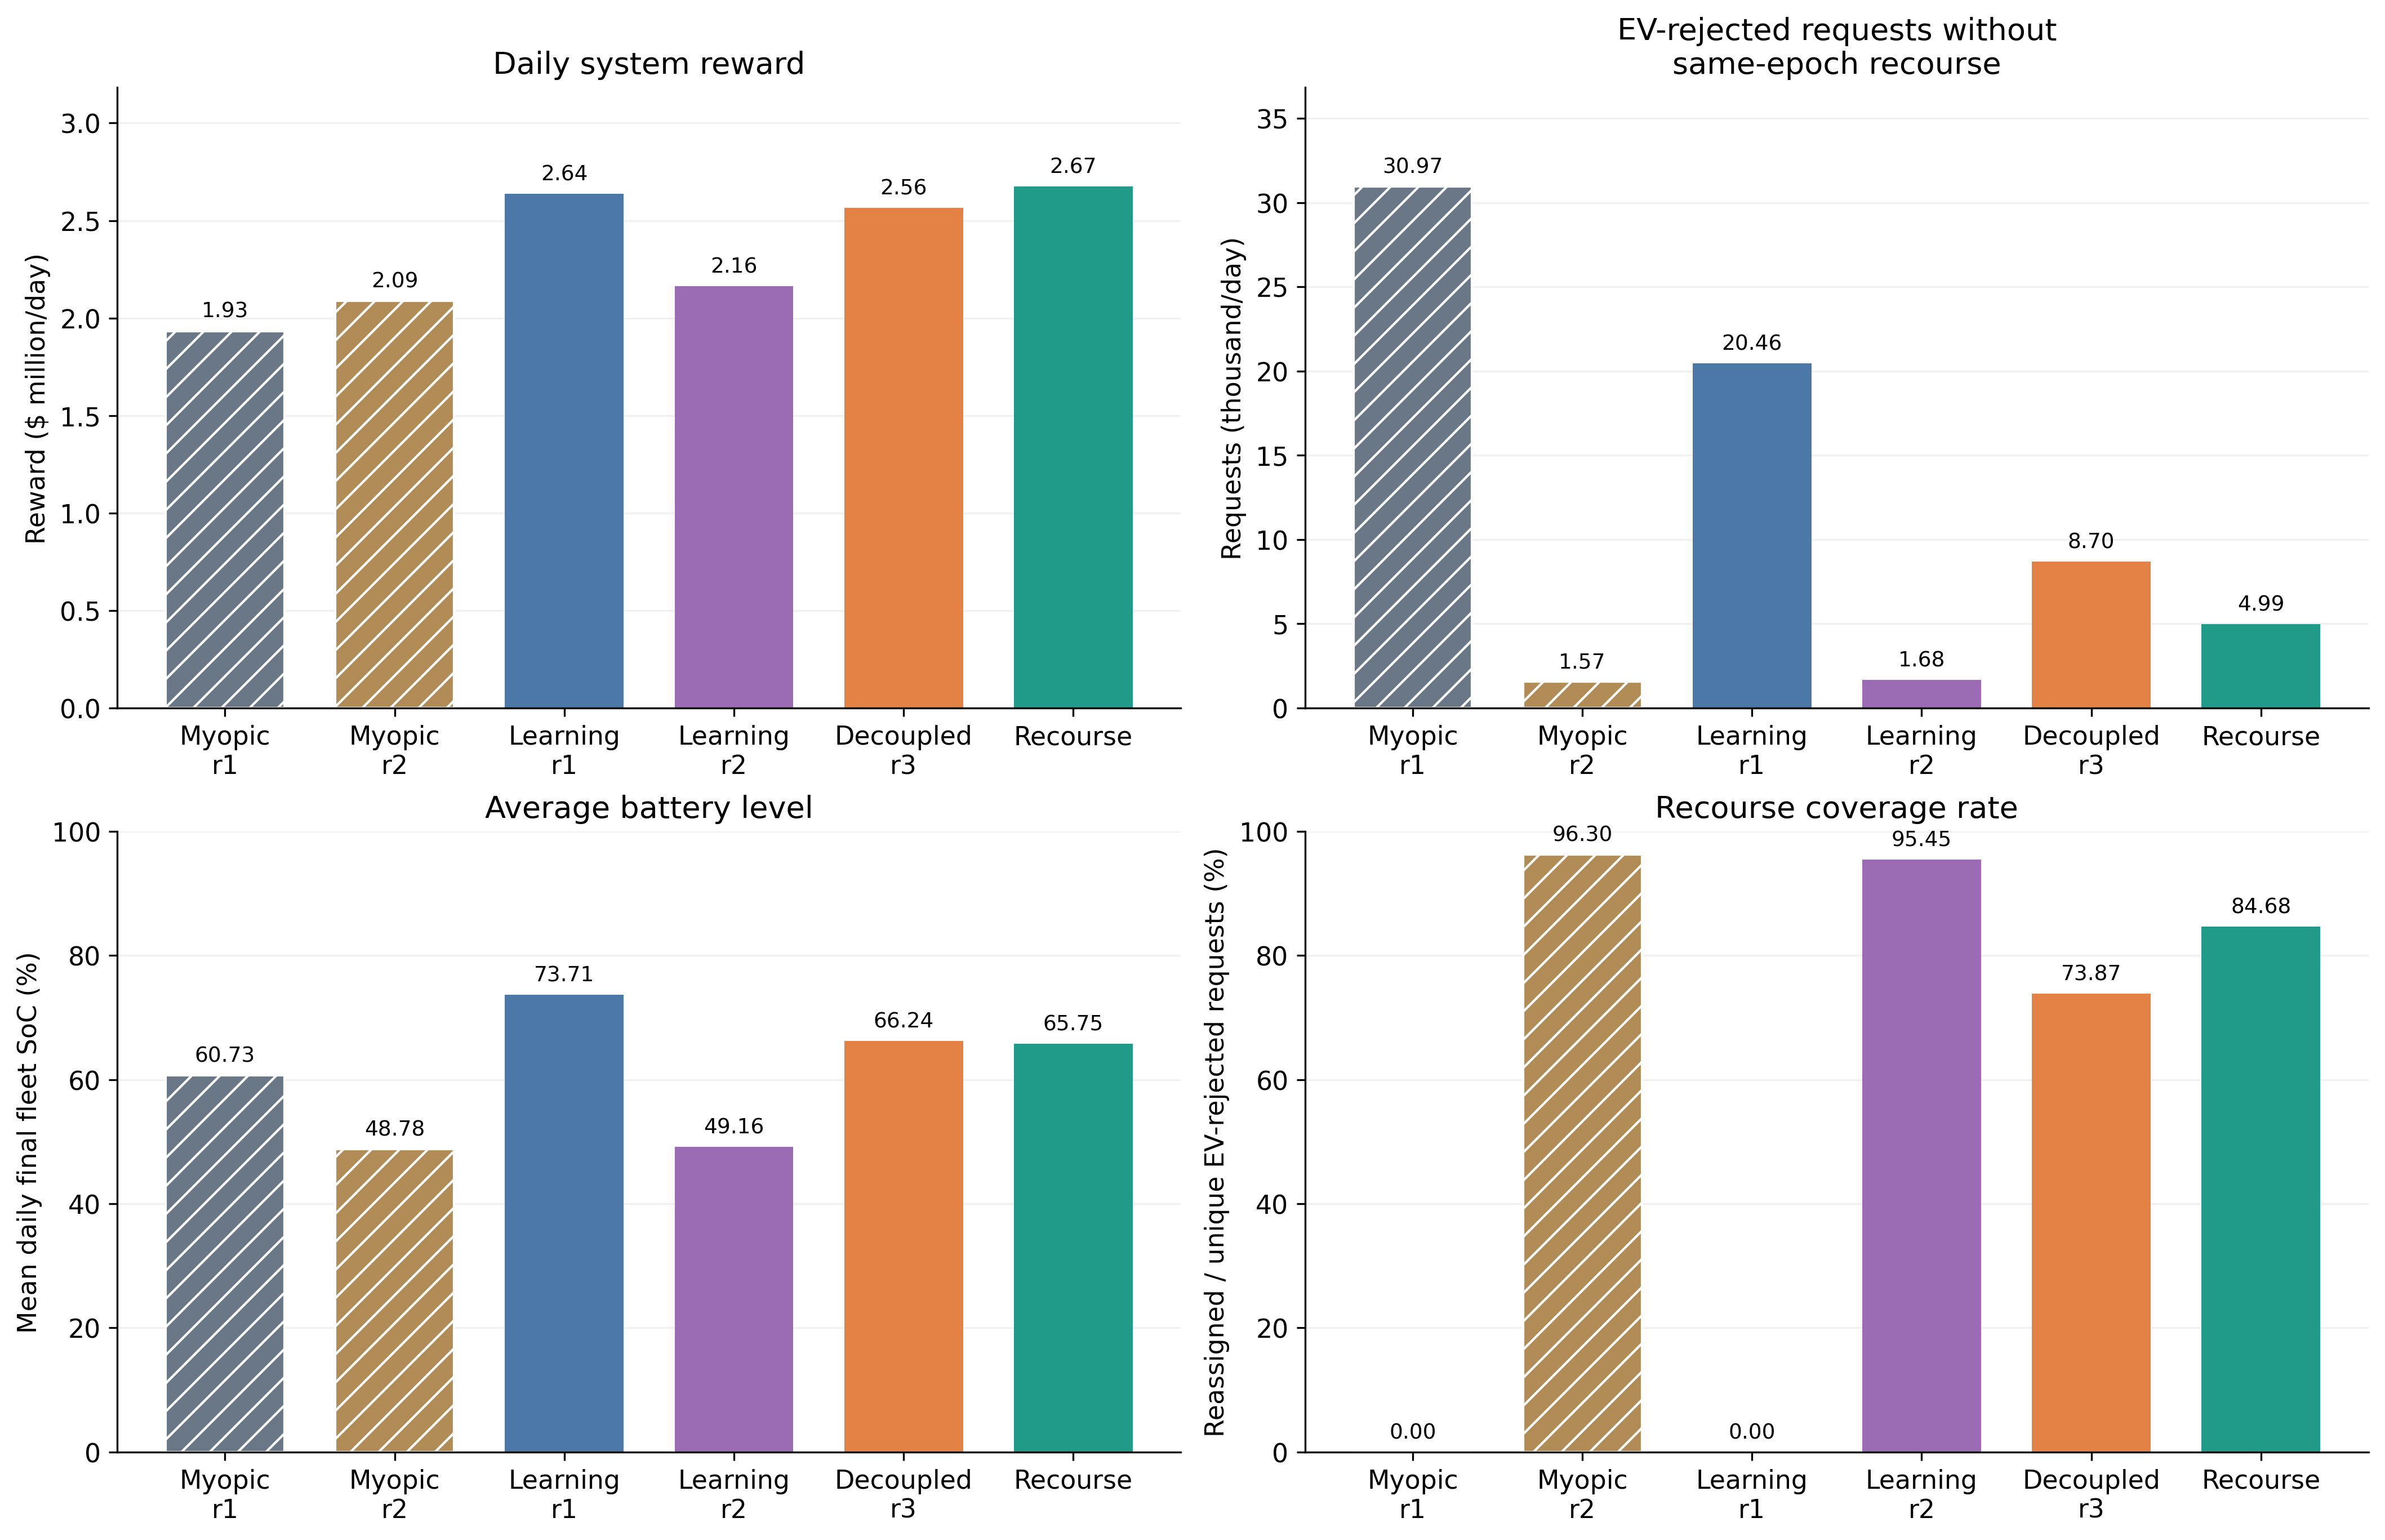

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), layout='constrained')
bars(axes[0, 0], metrics.reward_per_day / 1e6, 'Daily system reward', 'Reward ($ million/day)', '.2f')
bars(axes[0, 1], metrics.rejected_without_same_epoch_recourse_per_day / 1000,
     'EV-rejected requests without\nsame-epoch recourse', 'Requests (thousand/day)', '.2f')
bars(axes[1, 0], metrics.mean_daily_final_soc_pct, 'Average battery level',
     'Mean daily final fleet SoC (%)', '.2f')
axes[1, 0].set_ylim(0, 100)
bars(axes[1, 1], metrics.recourse_rate_pct, 'Recourse coverage rate',
     'Reassigned / unique EV-rejected requests (%)', '.2f')
axes[1, 1].set_ylim(0, 100)
# fig.suptitle('NYC policy comparison\n' + PERIOD, fontsize=16)
save_show(fig, '01_policy_overview', 'Daily reward, unrecovered same-epoch rejections, mean daily final fleet SoC, same-epoch recourse coverage')

## 图 2：六种方法的逐小时完成量与按天置信区间

同一张图画全部六种方法（包含两个 Myopic）；每条线为三天逐小时完成量的平均值，彩色带为名义 95% t 区间，样本单位是天。
灰色背景为共同外部需求的三天平均 KDE。完成时刻与订单生成时刻不同，不能把两条曲线相除当作该小时服务率。

,rejected_requests_total,recourse_requests_total,recourse_completed_requests_total,recourse_uncompleted_requests_total,rejected_without_same_epoch_recourse_total,rejected_without_same_epoch_recourse_per_day,lost_requests_total,daily_recourse_assignments,daily_lost_requests,recourse_rate_pct,recourse_completion_success_pct,recourse_over_recourse_plus_lost_pct
Method,,,,,,,,,,,,
Myopic r1,92898,0,NaN,NaN,92898,30966.00,72693,0.00,24231.00,0.00,NaN,0.00
Myopic r2,127086,122386,NaN,NaN,4700,1566.67,27346,40795.33,9115.33,96.30,NaN,81.74
Learning r1,61388,0,NaN,NaN,61388,20462.67,80250,0.00,26750.00,0.00,NaN,0.00
Learning r2,110501,105470,NaN,NaN,5031,1677.00,27682,35156.67,9227.33,95.45,NaN,79.21
Learning r3,99876,73780,NaN,NaN,26096,8698.67,79024,24593.33,26341.33,73.87,NaN,48.28
Recourse,97659,82701,NaN,NaN,14958,4986.00,54119,27567.00,18039.67,84.68,NaN,60.45


Method,Myopic r1,Myopic r2,Learning r1,Learning r2,Decoupled r3,Recourse
date,,,,,,
2025-12-15,87354,107018,97075,107142,98664,98149
2025-12-16,95097,109842,91931,111459,90043,98888
2025-12-17,99883,110948,86158,108975,87643,104043


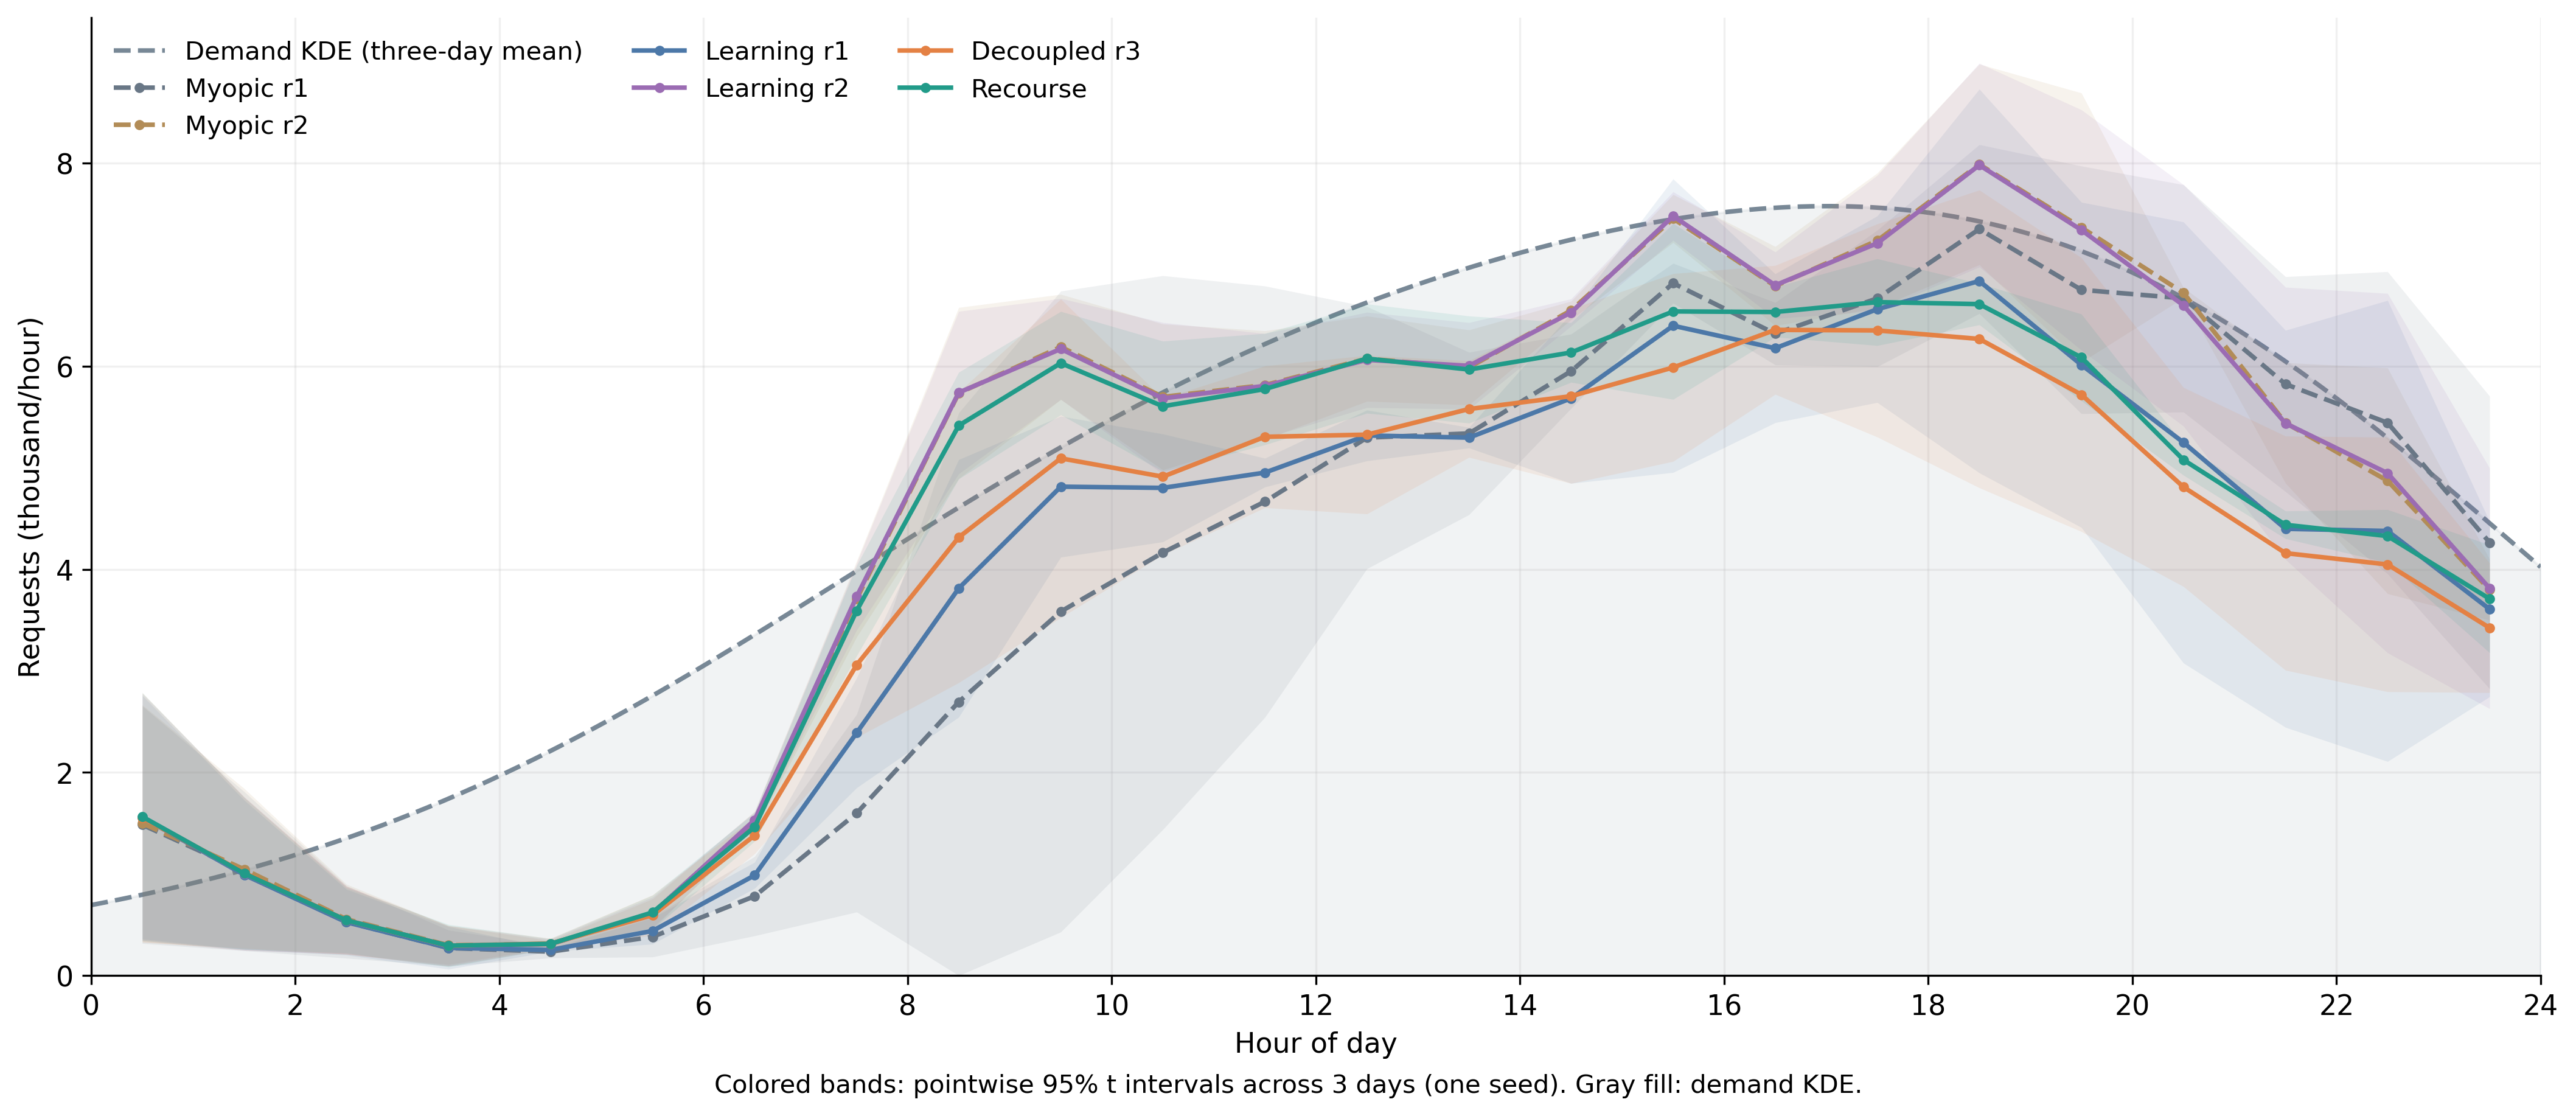

In [44]:
recourse_data = pd.DataFrame(index=ORDER)
recourse_data.index.name = 'Method'
recourse_data['rejected_requests_total'] = raw.rejected_requests
recourse_data['recourse_requests_total'] = raw.recourse_requests
recourse_data['recourse_completed_requests_total'] = raw.recourse_completed_requests
recourse_data['recourse_uncompleted_requests_total'] = raw.recourse_uncompleted_requests
recourse_data['rejected_without_same_epoch_recourse_total'] = metrics.rejected_without_same_epoch_recourse_total
recourse_data['rejected_without_same_epoch_recourse_per_day'] = metrics.rejected_without_same_epoch_recourse_per_day
recourse_data['lost_requests_total'] = raw.lost_requests
recourse_data['daily_recourse_assignments'] = raw.recourse_requests / N_DAYS
recourse_data['daily_lost_requests'] = raw.lost_requests / N_DAYS
recourse_data['recourse_rate_pct'] = metrics.recourse_rate_pct
recourse_data['recourse_completion_success_pct'] = metrics.recourse_completion_success_pct
# 旧图的描述性比值仅保留在 CSV 中，不能称为 recourse rate 或 success rate。
denominator = recourse_data.recourse_requests_total + recourse_data.lost_requests_total
recourse_data['recourse_over_recourse_plus_lost_pct'] = 100 * recourse_data.recourse_requests_total / denominator.replace(0, np.nan)
display(recourse_data.round(2))
recourse_data.to_csv(ANALYSIS_DIR / 'recourse_comparison.csv')

from scipy.stats import gaussian_kde, t

LEARNING_ORDER = ['Learning r1', 'Learning r2', 'Learning r3', 'Macro']
hours = np.arange(24)
hour_centers = hours + .5
expected = pd.MultiIndex.from_product([DATES, hours], names=['date', 'hour'])
completion_rows, confidence_rows, kde_rows = [], [], []
for label in ORDER:
    h = books[label]['hourly_completed_summary'].rename(columns={
        'completed_date': 'date', 'completed_hour': 'hour', 'mean_completed_orders': 'completed_orders'})
    counts = h.set_index(['date', 'hour']).completed_orders.sort_index()
    assert counts.index.equals(expected), f'{label}: incomplete completion hours'
    assert counts.notna().all() and (counts >= 0).all()
    detail = counts.rename('completed_orders').reset_index().assign(Method=label)
    completion_rows.append(detail)
    hourly = detail.groupby('hour').completed_orders.agg(['mean', 'std', 'count'])
    assert (hourly['count'] == N_DAYS).all()
    hourly['half_width'] = t.ppf(.975, hourly['count'] - 1) * hourly['std'] / np.sqrt(hourly['count'])
    hourly['lower_raw'] = hourly['mean'] - hourly['half_width']
    hourly['upper_raw'] = hourly['mean'] + hourly['half_width']
    hourly['lower_plot'] = hourly.lower_raw.clip(lower=0)
    hourly['Method'] = label
    confidence_rows.append(hourly.reset_index())
    np.testing.assert_allclose(hourly['mean'].sum(), raw.loc[label, 'complete'] / N_DAYS)

completion_detail = pd.concat(completion_rows, ignore_index=True)
confidence = pd.concat(confidence_rows, ignore_index=True)
completion_detail.to_csv(ANALYSIS_DIR / 'completed_hourly.csv', index=False)
confidence.to_csv(ANALYSIS_DIR / 'completed_hourly_day_confidence.csv', index=False)
daily_completion = completion_detail.groupby(['date', 'Method']).completed_orders.sum().unstack('Method')[ORDER]
daily_completion.to_csv(ANALYSIS_DIR / 'completed_daily.csv')
display(daily_completion.rename(columns=DISPLAY_LABELS))

demand = books[ORDER[0]]['hourly_req_completion_summary']
demand_by_hour = demand.groupby(['request_date', 'request_hour']).generated_requests.sum()
demand_by_hour.index = demand_by_hour.index.set_names(['date', 'hour'])
assert demand_by_hour.index.equals(expected)
demand_by_hour.rename('generated_requests').to_csv(ANALYSIS_DIR / 'demand_hourly.csv')
KDE_BW_METHOD = .7
kde_x = np.linspace(0, 24, 481)
for date in DATES:
    values = demand_by_hour.xs(date, level='date').reindex(hours).to_numpy()
    assert values.sum() > 0
    kde = gaussian_kde(hour_centers, weights=values, bw_method=KDE_BW_METHOD)
    rate = kde(kde_x) / kde.integrate_box_1d(0, 24) * values.sum()
    np.testing.assert_allclose(np.trapezoid(rate, kde_x), values.sum(), rtol=1e-4)
    kde_rows.append(pd.DataFrame({'date': date, 'hour': kde_x, 'demand_requests_per_hour': rate}))
kde_detail = pd.concat(kde_rows, ignore_index=True)
kde_detail.to_csv(ANALYSIS_DIR / 'demand_kde_daily.csv', index=False)
mean_demand = kde_detail.groupby('hour').demand_requests_per_hour.mean()

fig, ax = plt.subplots(figsize=(14, 6), layout='constrained')
ax.fill_between(kde_x, mean_demand / 1000, color='#aeb8c2', alpha=.17, zorder=0)
ax.plot(kde_x, mean_demand / 1000, color='#788896', linestyle='--', linewidth=1.8,
        label='Demand KDE (three-day mean)', zorder=1)
for label in ORDER:
    c = confidence[confidence.Method == label].sort_values('hour')
    ax.fill_between(hour_centers, c.lower_plot.to_numpy()/1000, c.upper_raw.to_numpy()/1000,
                    color=COLORS[label], alpha=.10, linewidth=0, zorder=2)
    ax.plot(hour_centers, c['mean'].to_numpy()/1000, label=DISPLAY_LABELS[label],
            color=COLORS[label], linestyle=STYLE[label], marker='o', markersize=3,
            linewidth=2.8 if label == 'Macro' else 1.8, zorder=3)
ax.set(xlabel='Hour of day', ylabel='Requests (thousand/hour)', xlim=(0,24))
ax.set_xticks(np.arange(0,25,2))
ax.set_ylim(bottom=0)
ax.legend(ncol=3, frameon=False, loc='upper left', fontsize=10)
fig.supxlabel(f'Colored bands: pointwise 95% t intervals across {N_DAYS} days (one seed). Gray fill: demand KDE.', fontsize=10)
save_show(fig, '02_completed_demand_confidence', 'Six policies: mean hourly completions with nominal pointwise 95% t intervals across days and shared mean demand KDE')

## Macro 与 Decoupled r3：补充比较

比较拒单事件、去重拒单订单、重复拒单事件以及补救覆盖率。旧文件缺少补救完成计数时保持 n/a，不能用所有完成订单代替。
这些是各方法运行结果的描述性比较，不是同一批拒单上的配对因果实验。

In [45]:
comparison = pd.DataFrame(index=['Decoupled r3', 'Recourse'])
for name, key in [('Decoupled r3', 'Learning r3'), ('Recourse', 'Recourse')]:
    r = raw.loc[key]
    comparison.loc[name, 'rejection_events'] = r['reject']
    comparison.loc[name, 'unique_rejected_requests'] = r.rejected_requests
    comparison.loc[name, 'repeat_rejection_events_after_first'] = r['reject'] - r.rejected_requests
    comparison.loc[name, 'rejection_events_per_rejected_request'] = r['reject'] / r.rejected_requests
    comparison.loc[name, 'same_epoch_recourse_assignments'] = r.recourse_requests
    comparison.loc[name, 'completed_recourse_requests'] = r.recourse_completed_requests
    comparison.loc[name, 'recourse_coverage_pct'] = metrics.loc[key, 'recourse_rate_pct']
    comparison.loc[name, 'recourse_completion_success_pct'] = metrics.loc[key, 'recourse_completion_success_pct']
comparison = comparison.T
comparison.index.name = 'Metric'
comparison['Recourse_minus_r3'] = comparison['Recourse'] - comparison['Decoupled r3']
comparison['relative_change_pct'] = 100 * comparison['Recourse'] / comparison['Decoupled r3'] - 100
comparison['difference_unit'] = ['percentage points' if c.endswith('_pct') else 'native units' for c in comparison.index]
display(comparison.round(4))
comparison.to_csv(ANALYSIS_DIR / 'macro_vs_decoupled_recourse_diagnostics.csv')

from IPython.display import Markdown
event_delta = comparison.loc['rejection_events', 'relative_change_pct']
repeat_delta = comparison.loc['repeat_rejection_events_after_first', 'relative_change_pct']
coverage_delta = comparison.loc['recourse_coverage_pct', 'Recourse_minus_r3']
success_delta = comparison.loc['recourse_completion_success_pct', 'Recourse_minus_r3']
display(Markdown(
    f"当前 Recourse 相对 r3 的拒单事件变化为 **{event_delta:+.2f}%**，"
    f"首次拒单以外的额外拒单事件变化为 **{repeat_delta:+.2f}%**；"
    f"同轮补救覆盖率变化 **{coverage_delta:+.2f} 个百分点**。"
    f"再指派后的完成率只变化 **{success_delta:+.4f} 个百分点**，基本相同。\n\n"
    "这些结果与 recourse-aware 学习改善前后阶段协调、减少反复拒单的解释相容，"
    "但仅凭一次评估不能确认机制因果。当前优势主要体现在拒单过程，"
    "而不是补救执行次数更多或补救后的完成概率更高。"
))


,Decoupled r3,Recourse,Recourse_minus_r3,relative_change_pct,difference_unit
Metric,,,,,
rejection_events,146854.0000,125846.0000,-21008.0000,-14.3054,native units
unique_rejected_requests,99876.0000,97659.0000,-2217.0000,-2.2198,native units
repeat_rejection_events_after_first,46978.0000,28187.0000,-18791.0000,-39.9996,native units
rejection_events_per_rejected_request,1.4704,1.2886,-0.1817,-12.3600,native units
same_epoch_recourse_assignments,73780.0000,82701.0000,8921.0000,12.0914,native units
completed_recourse_requests,NaN,NaN,NaN,NaN,native units
recourse_coverage_pct,73.8716,84.6834,10.8118,14.6360,percentage points
recourse_completion_success_pct,NaN,NaN,NaN,NaN,percentage points


当前 Recourse 相对 r3 的拒单事件变化为 **-14.31%**，首次拒单以外的额外拒单事件变化为 **-40.00%**；同轮补救覆盖率变化 **+10.81 个百分点**。再指派后的完成率只变化 **+nan 个百分点**，基本相同。

这些结果与 recourse-aware 学习改善前后阶段协调、减少反复拒单的解释相容，但仅凭一次评估不能确认机制因果。当前优势主要体现在拒单过程，而不是补救执行次数更多或补救后的完成概率更高。

## 保存与验证

图像保留图中数值；CSV 保留未四舍五入的数据。检查所有原始 Excel 的 SHA-256，确保来源未被改动。

In [46]:
assert len(FIGURES) == 2
for source in source_info:
    assert hashlib.sha256((DATA_DIR / source['file']).read_bytes()).hexdigest() == source['sha256'], '原始工作簿发生变化'
manifest = {
    'seed': SEED, 'days': N_DAYS, 'dates': [pd.Timestamp(d).strftime('%Y-%m-%d') for d in DATES],
    'sources': source_info, 'figures': FIGURES,
    'method_labels': DISPLAY_LABELS,
    'uncertainty': {'method': 'pointwise mean +/- Student t(.975, n-1) * sample SD / sqrt(n)',
                    'sample_unit': 'calendar day', 'n': N_DAYS, 'seeds': 1,
                    'limitation': 'nominal interval assuming exchangeable independent days; three different-demand dates, not repeated seeds',
                    'plot_lower_bound': 'clipped at zero; raw bounds retained in CSV'},
    'battery': 'mean of daily final fleet SOC, includes EV and AEV; not a time average',
    'recourse_coverage': '100 * unique same-epoch recourse assignments / unique EV-rejected requests',
    'demand_kde': {'bw_method': KDE_BW_METHOD, 'normalization': 'each day integrates to its demand; then mean across days',
                   'shading': 'gray fill is demand, not confidence'},
    'latex': 'policy_comparison.tex',
}
(ANALYSIS_DIR / 'paper_figures_manifest.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print(f'{len(FIGURES)} figures saved as PNG + PDF to {FIG_DIR}')
print('LaTeX and underlying values:', ANALYSIS_DIR)
display(pd.DataFrame(FIGURES))

2 figures saved as PNG + PDF to /Users/seinzhou/Desktop/icaps/results/nye_results/paper_figures_single
LaTeX and underlying values: /Users/seinzhou/Desktop/icaps/results/nye_results/analysis_single


,name,description
0,01_policy_overview,"Daily reward, unrecovered same-epoch rejection..."
1,02_completed_demand_confidence,Six policies: mean hourly completions with nom...
